## Financial Trading with Python, 2nd Edition

Cordell L. Tanny, CFA, FRM, FDP

**Chapter 13: Algorithmic Trading Strategies**

Notebook 13.3: Antifragile Asset Allocation: A Sector Rotation Strategy with a Tail Hedge

Version: 1.0

Last revised: 2026-05-31

---

## Introduction

This notebook builds a monthly sector-rotation strategy with a tail-hedge overlay, adapted from Gioele Giordano's Antifragile Asset Allocation Model [https://www.naaim.org/wp-content/uploads/2019/05/00K_Antifragile-Asset-Allocation-Model_GioeleGiordano_1st-Place.pdf].

The idea is simple to state: each month we rank the eleven S&P sector funds by a composite score, hold the strongest ones equally weighted, and when there are not enough strong sectors to fill the book we top it up from a small sleeve of defensive assets (bonds, gold, a currency hedge, an inverse-equity fund), falling back to short-term Treasuries as cash when nothing has positive momentum.
The reason this strategy is here is not that it prints money. It works, but the angle for this chapter is skepticism about complexity. The original composite score has four separate components, and a natural question to ask of any multi-part model is whether each part is paying for itself. We present the full model faithfully, then take it apart one component at a time, and the result is that the elaborate four-factor score is not earning its keep. Momentum and a volatility filter carry the strategy, and the extra machinery does not improve things. That is a lesson worth far more than another backtest with a good Sharpe ratio: knowing when a model is overbuilt is part of the job.

This notebook covers:

- Setting up the strategy universe and downloading the price data
- Building the four ranking signals
- The composite score and the monthly rebalance
- Backtesting the strategy after costs
- How the strategy allocates over time
- Whether the complexity earns its place

## Setting up the strategy universe

Before anything else, the notebook prepares its own environment. It pulls the two helper modules and the package list from the book's repository, so nothing has to be uploaded into the session by hand.

Package versions live in one file in the repository rather than being written into each notebook. When a pinned version stops resolving, and eventually it will, the fix is a single commit instead of an edit to every notebook in the chapter.

This cell also sets where price data comes from. The `USE_SAVED_PRICES` flag controls it:

- `True`, the default, reads prices from files stored in the repository. Every figure printed in this chapter came from those exact files, so your results will match the book.
- `False` downloads fresh data from Yahoo Finance. The notebook still runs end to end, but your numbers will differ from the printed ones.

The reason for the saved files is worth stating. Yahoo recomputes its entire adjusted price history whenever a new dividend or split is recorded, so a series downloaded today is not the series downloaded last month, and across a twenty-year window those revisions compound. Without fixed data, a reader whose numbers differ has no way to tell whether the cause is data drift at the source or a mistake in their own setup.

In [1]:
# --- Environment and data source -------------------------------------------
# Fetches the helper modules and the package list from the book repository,
# installs, and reports what actually landed. Nothing needs uploading by hand.

import os, sys, subprocess, importlib

# True  : read prices from the saved files, results match the book
# False : download fresh from Yahoo, results will differ
USE_SAVED_PRICES = True

REPO_RAW = ('https://raw.githubusercontent.com/PacktPublishing/'
            'Hands-on-Financial-Trading-with-Python-Second-Edition/main')
SCRIPTS_URL = f'{REPO_RAW}/FINAL/python_scripts'
DATA_URL    = f'{REPO_RAW}/FINAL/chapter13/data_files'
REQS_URL    = f'{REPO_RAW}/FINAL'

# Versions this chapter was written against. Used only for the report below.
TESTED = {'python': '3.13', 'numpy': '2.1.3', 'pandas': '2.2.3',
          'vectorbt': '0.28.5', 'pyarrow': '18.1.0', 'yfinance': '0.2.66'}


def fetch(fname, url_base):
    """Download a file into the session if it is not already there."""
    if os.path.exists(fname):
        print(f'  using local {fname}')
        return fname
    subprocess.run(['wget', '-q', f'{url_base}/{fname}'])
    if not os.path.exists(fname):
        raise FileNotFoundError(f'Could not fetch {fname} from {url_base}')
    print(f'  fetched {fname}')
    return fname


def fetch_data_file(fname):
    """Return a local path to a saved data file, downloading it once if needed."""
    return fetch(fname, DATA_URL)


# A pinned package with no wheel for your Python does not fail cleanly: pip
# tries to build from source and the runtime usually dies first. Checking here
# turns that into a readable message.
PY = f'{sys.version_info.major}.{sys.version_info.minor}'
if PY != TESTED['python']:
    print(f'NOTE: this chapter was tested on Python {TESTED["python"]}; you are on {PY}.')
    print('      If the install below hangs, a pinned package has no wheel for '
          'your Python.\n')

fetch('requirements-ch13.txt', REQS_URL)
fetch('functions.py', SCRIPTS_URL)
fetch('vectorbt_harness.py', SCRIPTS_URL)

# No -q here. A silent install that fails leaves you debugging an ImportError
# several cells later instead of reading the actual error now.
print('\nInstalling...')
!pip install -r requirements-ch13.txt 2>&1 | tail -6

print(f'\n{"package":<12}{"installed":<14}{"tested":<12}')
print('-' * 38)
print(f'{"python":<12}{PY + "." + str(sys.version_info.micro):<14}{TESTED["python"]:<12}')
for pkg in ['numpy', 'pandas', 'pyarrow', 'vectorbt', 'numba', 'yfinance']:
    try:
        v = importlib.import_module(pkg).__version__
    except Exception:
        v = 'not installed'
    flag = '' if TESTED.get(pkg) in (None, v) else '  <- differs'
    print(f'{pkg:<12}{v:<14}{TESTED.get(pkg, "-"):<12}{flag}')

print(f'\nUSE_SAVED_PRICES = {USE_SAVED_PRICES}'
      f'  ({"saved files, results match the book" if USE_SAVED_PRICES else "live download, results will differ"})')

  fetched requirements-ch13.txt
  fetched functions.py
  fetched vectorbt_harness.py

Installing...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 26.9 MB/s eta 0:00:00

package     installed     tested      
--------------------------------------
python      3.13.15       3.13        
numpy       2.1.3         2.1.3       
pandas      2.2.3         2.2.3       
pyarrow     18.1.0        18.1.0      
vectorbt    0.28.5        0.28.5      
numba       0.61.2        -           
yfinance    0.2.66        0.2.66      

USE_SAVED_PRICES = True  (saved files, results match the book)


The strategy draws on two groups of assets that play different roles.

- The first group is the rotation engine: eleven sector and property funds that between them cover the broad United States equity market. In a typical month the strategy is almost entirely invested in the strongest of these.
- The second group is the defensive sleeve, sometimes called the black-swan sleeve because its job is to be there when equities fall apart. It holds bonds of different maturities, gold, two currency hedges, and an inverse-equity fund that rises when the market drops.

Every month we score the assets, hold the best names equally weighted, and fill any empty slots from the defensive sleeve. When even the defensive names lack positive momentum, the unused portion goes to a short-term Treasury fund (SHY) that stands in for cash. The portfolio is rebalanced once a month and never holds more than five names at a time, each at twenty percent.

One point of accuracy before we start. We follow the strategy as the paper specifies it in every respect but one: we measure momentum over twelve months rather than the paper's four. That is a deliberate change, and we show why with a parameter sweep later in the notebook. Everywhere else, the universe, the scoring, and the slot-filling allocation, we follow the paper, and we flag any place a detail needs interpretation when we reach it.

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# --- Paper's exact universe ---
SECTORS = ['XLY','XLV','XLU','XLP','XLK','XLI','XLF','XLE','XLB','VOX','RWR']
HEDGES  = ['FXY','FXF','GLD','IEF','SH','TLT','SHY']
CASH    = 'SHY'                       # fallback when nothing has positive momentum
ALL_TICKERS = SECTORS + [h for h in HEDGES if h not in SECTORS]

# --- Periods from the source (in trading days unless noted) ---
ROC_PERIOD       = 12 * 21            # 12-month absolute momentum (production lookback, assuming 21 days in a month)
ATR_PERIOD       = 42                 # ATR lookback for the trend term
HIGH_CLOSE_PERIOD = 63                # upper-band highest-close lookback
HIGH_LOW_PERIOD  = 105                # lower-band highest-low lookback
VOL_MONTHS       = 36                 # realized-vol window (GARCH stand-in), in months
CORR_PERIOD      = 4 * 21             # 4-month correlation window, assuming 21 days in a month
TOP_SECTORS      = 5
TOP_HEDGES       = 3

START_DATE = '2007-01-01'             # pull early; SH/VOX/RWR etc. warm up staggered
END_DATE   = '2026-05-31'

# --- Download daily OHLC data ---
# We need three price series per asset, not just the close:
#   High and Low feed the true-range calculation behind the ATR trend term (T).
#     True range looks at the full daily trading range and the gap from the
#     prior close, so it needs the high and the low, not only the closing price.
#   Close drives everything else: momentum (ROC), realized volatility, and
#     the correlation component.
# auto_adjust=True returns prices already adjusted for splits and dividends,
# so the high, low, and close stay consistent with each other.
# Both branches produce the same frame: the full yfinance OHLCV panel, which is
# what the High and Low series above are read from. Everything below is unchanged.
if USE_SAVED_PRICES:
    raw = pd.read_parquet(fetch_data_file('ch13_nb03_signal_prices.parquet'))
else:
    raw = yf.download(ALL_TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True)
cols = [t for t in ALL_TICKERS if t in raw['Close'].columns]
high   = raw['High'][cols].copy()
low    = raw['Low'][cols].copy()
close  = raw['Close'][cols].copy()

print(f"Tickers requested: {len(ALL_TICKERS)}, returned: {len(cols)}")
missing = [t for t in ALL_TICKERS if t not in cols]
print(f"Missing: {missing if missing else 'none'}")
print(f"Date range: {close.index.min().date()} to {close.index.max().date()}")
print(f"\nFirst valid close per ticker (staggered inception):")
print(close.notna().idxmax().sort_values().to_string())

  fetched ch13_nb03_signal_prices.parquet
Tickers requested: 18, returned: 18
Missing: none
Date range: 2007-01-03 to 2026-05-29

First valid close per ticker (staggered inception):
Ticker
XLY   2007-01-03
SH    2007-01-03
IEF   2007-01-03
GLD   2007-01-03
FXF   2007-01-03
RWR   2007-01-03
VOX   2007-01-03
TLT   2007-01-03
XLB   2007-01-03
XLF   2007-01-03
XLI   2007-01-03
XLK   2007-01-03
XLP   2007-01-03
XLU   2007-01-03
XLV   2007-01-03
XLE   2007-01-03
SHY   2007-01-03
FXY   2007-02-13


All eighteen tickers came back. The print of the first valid close per ticker shows that most of them start on 2007-01-03, with one exception: FXY, the Japanese-yen currency fund, does not begin until 2007-02-13. That staggered start does not cause a problem, because the slowest signal we build needs thirty-six months of history to warm up. Once that warmup is accounted for, the first rebalance the strategy can act on is at the end of January 2010, and the backtest runs from there to the end of the data.

## Building the four ranking signals

The composite score, which the source calls TRank, combines four measurements. We compute each one for every asset, then rank assets against each other within their own group. Here is what each measurement captures, in plain terms.

- M, momentum: the rate of change of price over the lookback window, meaning today's price divided by the price one window ago, minus one. A positive value means the asset is higher than it was a year ago. We use a twelve-month window in this production notebook.
- V, volatility: how much the asset's monthly returns have bounced around, measured as the standard deviation of the trailing thirty-six monthly returns. A lower value means a calmer asset. This is a stand-in for the GARCH(1,1) model the original strategy uses, and the next paragraph explains the substitution.
- C, correlation: how closely an asset moves with the other members of its own group, averaged over a four-month window. A lower value means the asset diversifies the group rather than duplicating it.
- T, trend: a plus-one, zero, or minus-one flag built from a comparison of two price bands, described below. It nudges the score up or down depending on the direction the bands imply.

On the volatility substitution: the original strategy forecasts next month's volatility with a GARCH(1,1) model, which is a statistical model that lets recent turbulence carry forward and decay over time. Fitting and forecasting GARCH for every asset every month is a lot of machinery, and for a monthly strategy the trailing standard deviation tracks it closely enough to use as a faithful stand-in. The trade-off between model complexity and practical benefit is the same theme we met when we looked at signal processing earlier in the book, and GARCH is a reasonable later refinement if you want to revisit it, but it is not where the value of this strategy lives.

The trend term needs one more piece of background, because it is built on the average true range, or ATR, and this is the strategy where ATR first appears in the book, so we explain it from the ground up.
ATR measures how much room a price has been moving through on a typical day. Some assets drift in small steps; others swing widely from one day to the next. ATR puts a single number on that daily movement, stated in the asset's own price units (dollars for a stock or fund), so a calm asset has a small ATR and a turbulent one has a large ATR.

The building block is the true range for a single day, which is the largest of these three distances:

- The day's high minus the day's low
- The day's high minus the previous day's close
- The day's low minus the previous day's close

We take the largest of the three rather than just the high minus the low because prices gap. A gap is a jump between one day's close and the next day's open, and on a gap day the real distance the price travelled is the move from yesterday's close, not just today's high-to-low span. Bringing in the previous close catches that jump, which is what makes it a true range.

The average true range is then the average of those daily true ranges over a lookback window. In this strategy the window is forty-two trading days, about two months, set in the parameter block as `ATR_PERIOD`.

The source then builds two price bands from the ATR. The upper band is the ATR added to the highest close over the last sixty-three days, and the lower band is the ATR added to the highest low over the last one hundred and five days. The trend term is plus one when the upper band sits above the lower band, minus one when the lower band sits above the upper band, and zero when they tie.

It is worth pausing on how the lower band can ever sit above the upper band, since at first glance the upper band sounds like it should always be larger. Both bands add the same ATR, so the ATR cancels and the comparison comes down to the highest close over sixty-three days against the highest low over one hundred and five days. The lookback lengths differ, and that is what drives the flip: the lower band looks back further, so it can still remember an old price peak that the shorter sixty-three-day window has already dropped. When that older peak is the bigger number, meaning the price has not pushed to fresh highs recently, the lower band wins and the term reads minus one. When recent action is making new highs, the upper band wins and the term reads plus one. The choice of close on the upper band and low on the lower band is a secondary nudge, since a close usually sits at or above the day's low, so the window-length gap has to be wide enough to overcome that before a minus one appears.

We replicate this exactly as written, and then we check whether it actually does anything, because a flag that is almost always the same value adds nothing to a ranking. As you will see, the construction is somewhat idiosyncratic, comparing a highest close against a highest low is not a standard indicator, which is part of why the term turns out to carry only weak information when we test it.

In [3]:
# --- M: 12-month absolute momentum (rate of change) ---
# ROC over ROC_PERIOD trading days: today's close / close ROC_PERIOD days ago - 1.
roc = close.pct_change(ROC_PERIOD)

# --- V: realized volatility as the GARCH stand-in ---
# The source fits GARCH(1,1) on 36 monthly returns and forecasts one-month vol.
# The faithful stand-in is the std of the trailing 36 monthly returns, computed
# on month-end closes. We build a monthly vol frame and will look up the value
# as of each rebalance date.
monthly_close = close.resample('ME').last()
monthly_ret = monthly_close.pct_change()
realized_vol_m = monthly_ret.rolling(VOL_MONTHS).std()   # indexed at month-end

# --- ATR per asset (simple MA of true range, matching the source's SMA ATR) ---
prev_close = close.shift(1)
tr = pd.concat([high - low,
                (high - prev_close).abs(),
                (low - prev_close).abs()]).groupby(level=0).max()
atr = tr.rolling(ATR_PERIOD).mean()

# --- T: ATR trend term, replicated exactly from the source ---
# upper_band = ATR + highest close over HIGH_CLOSE_PERIOD (63d)
# lower_band = ATR + highest low   over HIGH_LOW_PERIOD  (105d)
# directionality = +1 if upper > lower, -1 if lower > upper, else 0.
# Replicated as written; we report below whether it is effectively constant.
highest_close = close.rolling(HIGH_CLOSE_PERIOD).max()
highest_low   = low.rolling(HIGH_LOW_PERIOD).max()
upper_band = atr + highest_close
lower_band = atr + highest_low
atr_trend = pd.DataFrame(0, index=close.index, columns=close.columns)
atr_trend[upper_band > lower_band] = 1
atr_trend[lower_band > upper_band] = -1

# --- Daily returns frame for the correlation component (built in the loop) ---
daily_ret = close.pct_change()

# --- Report whether the T term is inert, as promised ---
print("ATR trend term (T) value distribution across all assets/days:")
vals = atr_trend.values.ravel()
vals = vals[~pd.isna(vals)]
print(pd.Series(vals).value_counts(normalize=True).apply(lambda x: f"{x:.1%}").to_string())
print(f"\nPer-asset share of days T = +1:")
print((atr_trend == 1).mean().sort_values().apply(lambda x: f"{x:.1%}").to_string())

ATR trend term (T) value distribution across all assets/days:
 1    70.6%
-1    27.0%
 0     2.4%

Per-asset share of days T = +1:
Ticker
SH     40.7%
FXY    50.1%
FXF    59.4%
TLT    63.2%
GLD    68.1%
IEF    69.0%
XLE    69.6%
XLF    71.7%
VOX    73.0%
RWR    73.4%
XLU    76.9%
XLI    77.6%
XLV    77.8%
XLB    78.0%
XLY    78.5%
SHY    80.3%
XLP    82.0%
XLK    82.2%


The trend term is not inert. Across all assets and all days it is plus one about seventy-one percent of the time, minus one about twenty-seven percent of the time, and zero only about two percent of the time. More telling than the overall split is that the per-asset shares spread out, from around forty-one percent plus-one for the inverse-equity fund SH up to around eighty-two percent for XLK. Because the term varies both across assets and across time, it does carry some information into the ranking. Whether that information is worth a full quarter of the score is the question the knockout test answers later.

## The composite score and the monthly rebalance

With the four pieces in hand we can build the score. We do this separately for the sectors and for the hedges. Within each group we rank the members on three of the components:

- M is ranked so that stronger momentum ranks better.
- V is ranked so that lower volatility ranks better.
- C is ranked so that lower correlation to the rest of the group ranks better.

A rank here is just a position number. If a group has eleven members, the best on a component gets 11, the next gets 10, and so on down to 1. We then blend the three rank numbers, plus the trend flag T, into one composite score:

`TRank = 0.25 * Rank(M) + 0.25 * Rank(V) + 0.25 * Rank(C) - 0.25 * T + M / n`

Reading this left to right: the three ranks each get an equal quarter of the weight, the trend flag T is subtracted (so a plus-one trend lowers a name's score and a minus-one trend raises it), and the last term, M divided by n (the number of members in the group), is a small tiebreaker that nudges higher-momentum names up when scores are otherwise close. One detail worth noting: T enters as its raw plus-one, zero, or minus-one value, not as a rank like the other three factors. The paper's own description is slightly inconsistent on this point, labelling the term as a rank in its notes while writing the raw value in the formula. We follow the formula. We sort by TRank and take the top five sectors and the top three hedges.

Next we combine the two groups into the final portfolio, and we follow the paper's rule:

- Take the top five sectors. Each one with positive momentum is held at twenty percent.
- Any of those five slots left unfilled (a sector with negative momentum) is handed to the Black Swan hedge sleeve instead.
- If all five sectors have negative momentum, the hedge sleeve takes the whole portfolio.
- Whatever the hedge sleeve cannot fill with a positive-momentum hedge goes to SHY (a short-term Treasury fund) as cash.

The effect of this rule is that sectors get first claim on every slot, and the hedges and cash only appear when sectors drop out, which happens when those sectors lack positive momentum. So in calm markets the five slots are all sectors and the portfolio is effectively all equities, while the defensive assets step in only when sectors start failing the momentum test, which is exactly when the market is weakening. That is how the strategy shifts toward defense in a downturn without anyone deciding to. Keep this in mind when you read the allocation results below, because it is the reason the portfolio sits near ninety-seven percent in equities.

The one place we depart from the paper is the momentum lookback. The paper measures Absolute Momentum over four months; this notebook uses twelve. We made that change deliberately, and the parameter sweep near the end of the notebook shows why: momentum is the one setting the strategy is genuinely sensitive to, and longer lookbacks work steadily better, so the four-month value the paper uses is one of its weaker settings.

In [4]:
def rank_group(members, asof, asof_month):
    """
    Build the TRank for one group as of a rebalance date, replicating the
    source. Returns an ordered list of symbols (best first), positive-momentum
    names only. `asof` is a daily date; `asof_month` is its month-end label for
    the monthly realized-vol lookup.
    """
    members = [m for m in members if m in close.columns]

    # M: 12-month ROC as of today.
    m = {s: roc.loc[asof, s] for s in members}

    # V: realized vol as of the most recent completed month.
    v = {s: realized_vol_m.loc[asof_month, s] if asof_month in realized_vol_m.index
         else np.nan for s in members}

    # C: average 4-month correlation of each member to the rest of its group.
    window = daily_ret.loc[:asof, members].iloc[-CORR_PERIOD:]
    corr = window.corr()
    # average correlation to the OTHERS (subtract the self-correlation of 1).
    avg_corr = {s: (corr[s].sum() - 1) / (len(members) - 1) for s in members}

    # Drop any member with a missing component (not yet warmed up).
    valid = [s for s in members
             if pd.notna(m[s]) and pd.notna(v[s]) and pd.notna(avg_corr[s])]
    if not valid:
        return []

    # Ranks. Source: M ascending (rank 1 = worst), V descending (rank 1 = highest
    # vol), C descending (rank 1 = highest corr). Higher rank number = better on
    # M, worse on V and C. Replicated exactly.
    def ranks(d, reverse):
        order = sorted(d.items(), key=lambda kv: kv[1], reverse=reverse)
        return {k: i + 1 for i, (k, _) in enumerate(order)}

    m_rank = ranks({s: m[s] for s in valid}, reverse=False)
    v_rank = ranks({s: v[s] for s in valid}, reverse=True)
    c_rank = ranks({s: avg_corr[s] for s in valid}, reverse=True)

    n = len(valid)
    tranks = {}
    for s in valid:
        if m[s] > 0:                              # positive momentum only
            t = atr_trend.loc[asof, s]
            tranks[s] = (0.25*m_rank[s] + 0.25*v_rank[s] + 0.25*c_rank[s]
                         - 0.25*t + m[s]/n)
    return [k for k, _ in sorted(tranks.items(), key=lambda kv: kv[1], reverse=True)]


# --- Walk month-ends, build sparse monthly weights ---
month_ends = close.resample('ME').last().index
weights = []
weight_dates = []

for me in month_ends:
    # Use the last actual trading day on or before the month-end label.
    asof_slice = close.loc[:me]
    if asof_slice.empty:
        continue
    asof = asof_slice.index[-1]

    # Warmup guard: need the 36-month vol available.
    if me not in realized_vol_m.index or realized_vol_m.loc[me].notna().sum() == 0:
        continue
    if pd.isna(roc.loc[asof]).all():
        continue

    top_sectors = rank_group(SECTORS, asof, me)[:TOP_SECTORS]
    top_hedges  = rank_group(HEDGES,  asof, me)[:TOP_HEDGES]

    # Code's slot-filling: sectors first, then hedges, keep first 5.
    picks = (top_sectors + top_hedges)[:TOP_SECTORS]

    w = {t: 1.0 / TOP_SECTORS for t in picks}     # 20% each
    if len(picks) < TOP_SECTORS:                  # pad remainder with SHY cash
        w[CASH] = w.get(CASH, 0.0) + (TOP_SECTORS - len(picks)) / TOP_SECTORS

    weights.append(w)
    weight_dates.append(asof)

# Assemble into a sparse weights frame on the union of all held tickers.
all_held = sorted({t for wd in weights for t in wd})
W = pd.DataFrame(0.0, index=weight_dates, columns=all_held)
for d, wd in zip(weight_dates, weights):
    for t, val in wd.items():
        W.loc[d, t] = val

out_file = 'antifragile_weights.csv'
W.to_csv(out_file)

print(f"Rebalance dates: {len(W)}  ({W.index.min().date()} to {W.index.max().date()})")
print(f"Tickers ever held: {len(all_held)}")
print(f"\nMean weight per ticker across all rebalances (held names only):")
print((W.replace(0, np.nan).mean().sort_values(ascending=False)).apply(lambda x: f"{x:.1%}").to_string())
print(f"\nShare of months with any SHY cash padding: {(W[CASH] > 0).mean():.1%}" if CASH in W else "")
print(f"Mean number of names held per month: {(W != 0).sum(axis=1).mean():.1f}")

Rebalance dates: 197  (2010-01-29 to 2026-05-29)
Tickers ever held: 17

Mean weight per ticker across all rebalances (held names only):
SHY    27.5%
FXF    20.0%
FXY    20.0%
IEF    20.0%
GLD    20.0%
RWR    20.0%
SH     20.0%
XLB    20.0%
XLI    20.0%
XLY    20.0%
XLK    20.0%
XLF    20.0%
XLE    20.0%
XLP    20.0%
XLV    20.0%
VOX    20.0%
XLU    20.0%

Share of months with any SHY cash padding: 4.1%
Mean number of names held per month: 5.0


The strategy rebalances 197 times, once a month from the end of January 2010 to the end of May 2026, and over that span it holds seventeen of the eighteen tickers at one point or another. Two numbers describe how it behaves. It pads with SHY cash in only about four percent of months, so almost every month it finds five real names to hold. It holds 5.0 names per month on average, meaning the book is essentially always full. Every held name carries the flat twenty percent weight, and SHY is the one ticker with a higher average because it absorbs the occasional cash padding on top of any month it is held on merit.

## Backtesting the strategy

We hand the monthly weights file to the shared backtest harness, which buys and sells to hit those target weights on each rebalance date and tracks the resulting portfolio against a benchmark. The harness reports two versions of every result: one with no trading costs and one after costs. After costs means the figure already has the realistic frictions of trading subtracted out, the commissions and the small price slippage you pay to get in and out, so it is the number that reflects what you would actually have kept. We read the after-costs column throughout.

When the saved-price flag is on we hand the harness two frames alongside the weights: the prices for the traded tickers and the benchmark prices. Both are needed. The benchmark's first available day helps set where the backtest window starts, so leaving the benchmark to a live download would let the comparison window move even with the strategy prices fixed. The same two frames are reused for every harness call in this notebook, including the parameter sweeps and the knockout tests, so every result is scored on identical prices.

In [5]:
from vectorbt_harness import run_backtest

if USE_SAVED_PRICES:
    # Loaded once here and reused by every harness call below: the sweeps, the
    # knockout configurations, and the equal-weight benchmark. The saved frame
    # is wider than this strategy needs; the harness trims it to the window the
    # weights file implies.
    bt_prices = pd.read_parquet(fetch_data_file('ch13_nb03_backtest_prices.parquet'))
    bm_prices = pd.read_parquet(
        fetch_data_file('ch13_nb03_benchmark_prices.parquet')).iloc[:, 0]
else:
    bt_prices = None    # None means the harness downloads, as it always did
    bm_prices = None

res = run_backtest(out_file, benchmark='SPY', verbose=False,
                   prices=bt_prices, bench_prices=bm_prices)
print(res.metrics.to_string())

  fetched ch13_nb03_backtest_prices.parquet
  fetched ch13_nb03_benchmark_prices.parquet
                         Strategy No Cost Strategy w/ Costs SPY Buy & Hold
Total Return                      458.70%           396.75%        842.22%
Ann. Return (CAGR)                 11.05%            10.26%         14.64%
Ann. Volatility                    11.52%            11.55%         14.42%
Downside Deviation                  7.00%             7.12%          8.69%
Max Drawdown                      -19.19%           -19.44%        -23.93%
Max DD Duration (months)               20                21             23
Ulcer Index                         4.104             4.392          5.581
Sharpe Ratio                        0.959             0.888          1.015
Sortino Ratio                       1.578             1.441          1.685
Calmar Ratio                        0.576             0.528          0.612
Ulcer Performance Index             2.692             2.335          2.623
Win Rate (m

The result is a risk-managed equity rotation. After costs the strategy returns 10.25 percent a year against SPY's 14.64 percent, so it gives up about four and a third points of annual return to a straight buy-and-hold of the market. In exchange it takes less risk on every measure: annual volatility of 11.55 percent against SPY's 14.42 percent, and a worst drawdown (the largest peak-to-trough fall) of 19.48 percent against SPY's 23.93 percent. The Sharpe ratio, which is return earned per unit of volatility, comes in at 0.888 against SPY's 1.015, so on this particular risk-adjusted measure SPY still edges ahead.

That last point is worth sitting with rather than glossing over. The strategy does its job of cutting risk, but it does not beat the market on a risk-adjusted basis here, and that is a useful and realistic result. A strategy that lowers your drawdowns and your volatility has value to an investor who cannot stomach a full equity ride, even when its Sharpe ratio does not clear the benchmark. The fair reading is that this is a defensive rotation, not a free lunch. Also note that beating SPY is very difficult to do on an absolute performance basis. We could question whether this is the correct benchmark for this strategy.

## How the strategy allocates over time

Two pictures make the strategy's behavior concrete. The first is the equity curve, the growth of the portfolio against the benchmark over the whole period. The second splits the portfolio into its sector-equity sleeve and its defensive sleeve at each rebalance, so we can see when the strategy is fully invested and when it steps aside. Below the plots we list the months the defensive sleeve was meaningfully switched on, to check whether they line up with periods of real market stress.

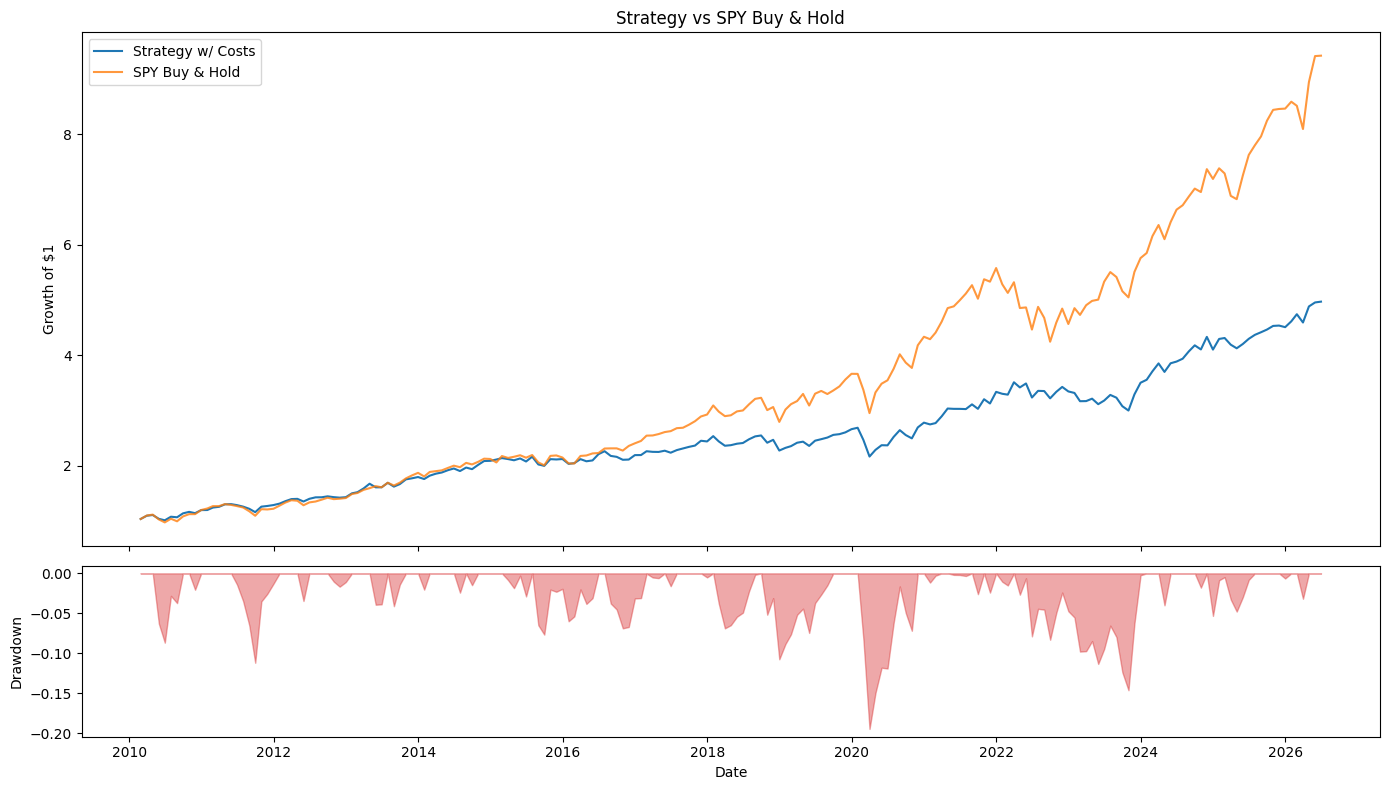

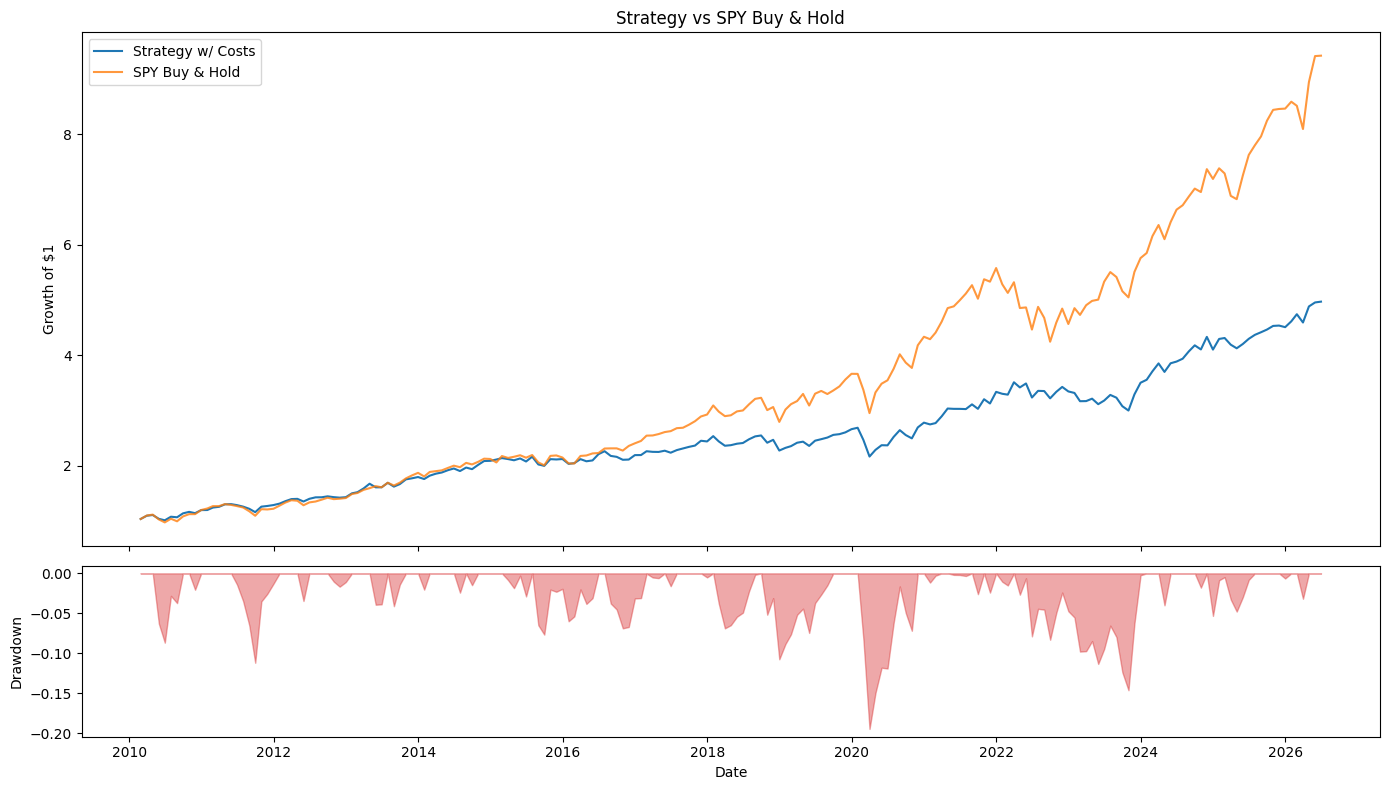

In [6]:
# --- Plot 1: equity curve (uses the harness's own monthly equity-vs-benchmark plot) ---
res.plot(use_costs=True)

In [7]:
# --- Average asset-class allocation over the backtest ---
# Classify every ticker the strategy can hold into a broad asset class.
CLASS = {
    # Sector ETFs: all equity
    'XLY':'Equity','XLV':'Equity','XLU':'Equity','XLP':'Equity','XLK':'Equity',
    'XLI':'Equity','XLF':'Equity','XLE':'Equity','XLB':'Equity','VOX':'Equity','RWR':'Equity',
    # Hedges
    'GLD':'Gold/Commodity',
    'FXY':'Currency','FXF':'Currency',
    'SH':'Inverse Equity',
    'IEF':'Bond','TLT':'Bond','SHY':'Bond/Cash',
}

# Map each held column to its class and sum weights within class, per rebalance.
classes = pd.Series({t: CLASS.get(t, 'Other') for t in W.columns})
by_class = W.T.groupby(classes).sum().T          # rows = rebalance dates, cols = classes

print("Mean allocation by asset class across all rebalances:")
print(by_class.mean().sort_values(ascending=False).apply(lambda x: f"{x:.1%}").to_string())

print(f"\nMean total: equity-like vs defensive")
equity_like = by_class.get('Equity', 0)
print(f"  Equity (sectors):        {by_class['Equity'].mean():.1%}")
defensive = by_class.reindex(columns=['Bond','Bond/Cash','Gold/Commodity','Currency','Inverse Equity'], fill_value=0).sum(axis=1)
print(f"  Defensive (bonds/gold/fx/short): {defensive.mean():.1%}")

print(f"\nEquity share distribution over time (percentiles):")
eq_share = by_class['Equity']

# describe() returns count alongside the distribution stats, but count is a
# number of rebalances, not a proportion. Formatting it as a percent gives
# a meaningless 19700.0%, so we pull it out and print it separately.
desc = eq_share.describe(percentiles=[.1, .25, .5, .75, .9])
n_rebalances = int(desc.pop('count'))

print(f"Rebalances: {n_rebalances}")
print(desc.apply(lambda x: f"{x:.1%}").to_string())

Mean allocation by asset class across all rebalances:
Equity            97.0%
Bond/Cash          1.1%
Inverse Equity     0.9%
Currency           0.4%
Gold/Commodity     0.4%
Bond               0.2%

Mean total: equity-like vs defensive
  Equity (sectors):        97.0%
  Defensive (bonds/gold/fx/short): 3.0%

Equity share distribution over time (percentiles):
Rebalances: 197
mean     97.0%
std      11.7%
min      40.0%
10%     100.0%
25%     100.0%
50%     100.0%
75%     100.0%
90%     100.0%
max     100.0%


The allocation tells a clear story. On average the strategy holds about ninety-seven percent in sector equity and only about three percent defensive, and the percentile breakdown shows the equity share sitting at one hundred percent from the tenth percentile all the way up, dropping to forty percent only at its single most defensive month. This is close to a pure sector rotation that stays fully invested in equities almost all the time and steps aside only in real stress, not a balanced fund that always carries a defensive cushion.

It is worth noting this is more equity-heavy than the shorter four-month momentum version of the strategy would be. The twelve-month lookback we chose keeps more sectors above the positive-momentum line in any given month, so fewer slots fall through to the hedge sleeve. The trade-off is direct: the longer lookback earns more return, which we saw in the metrics and will see again in the sweep, but it leaves the portfolio with a thinner defensive cushion.

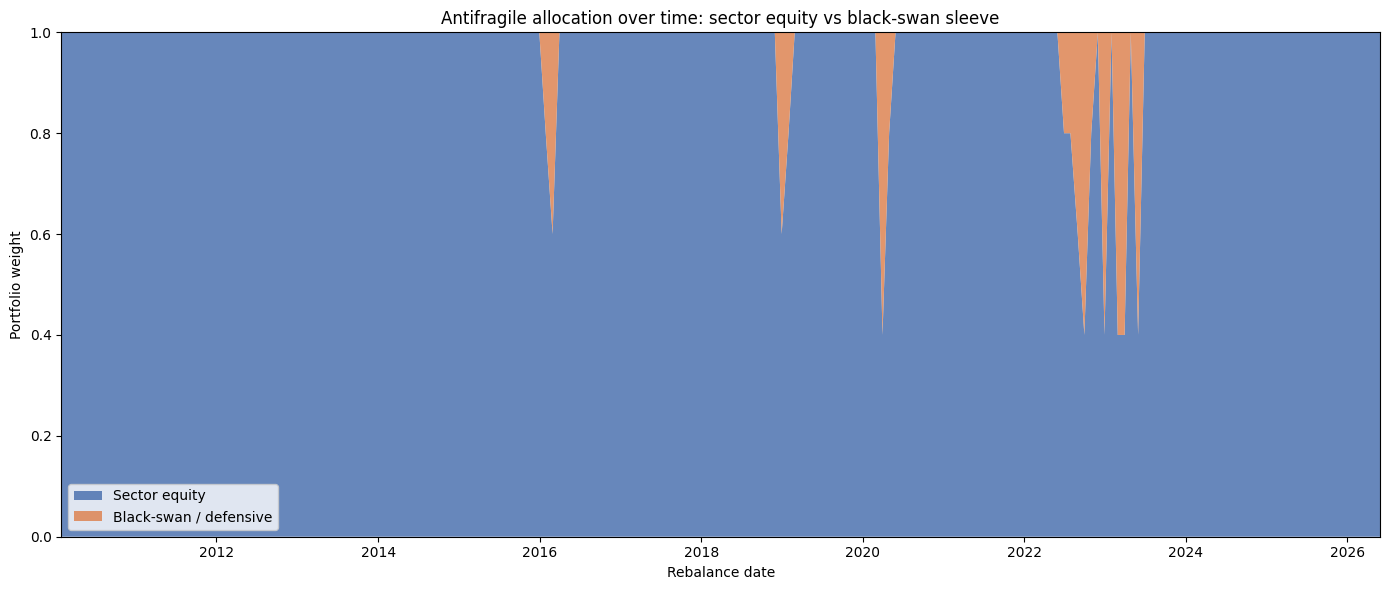

Months with defensive sleeve > 20%: 9 of 197
Dates:
2016-02-29    40%
2018-12-31    40%
2020-03-31    60%
2022-08-31    40%
2022-09-30    60%
2022-12-30    60%
2023-02-28    60%
2023-03-31    60%
2023-05-31    60%


In [8]:
# --- Plot 2: equity sleeve vs black-swan (defensive) sleeve over time ---
import matplotlib.pyplot as plt

# Equity sleeve = the 11 sectors; black-swan/defensive sleeve = everything else
# (bonds, gold, currency, inverse equity, SHY cash pad).
sector_share = by_class['Equity']
defensive_share = by_class.reindex(
    columns=['Bond', 'Bond/Cash', 'Gold/Commodity', 'Currency', 'Inverse Equity'],
    fill_value=0
).sum(axis=1)

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(
    sector_share.index,
    sector_share.values,
    defensive_share.values,
    labels=['Sector equity', 'Black-swan / defensive'],
    colors=['#4c72b0', '#dd8452'],
    alpha=0.85,
)
ax.set_ylim(0, 1)
ax.set_ylabel('Portfolio weight')
ax.set_xlabel('Rebalance date')
ax.set_title('Antifragile allocation over time: sector equity vs black-swan sleeve')
ax.legend(loc='lower left')
ax.margins(x=0)
plt.tight_layout()
plt.show()

# Mark the months the defensive sleeve was meaningfully on (>20%), to eyeball
# whether they line up with known stress periods.
on = defensive_share[defensive_share > 0.20]
print(f"Months with defensive sleeve > 20%: {len(on)} of {len(defensive_share)}")
print("Dates:")
print(on.apply(lambda x: f"{x:.0%}").to_string())

The picture confirms a near-fully-invested equity rotation that only occasionally steps aside. The defensive sleeve switches meaningfully on, above twenty percent, in just 9 of the 197 months, and those months land where you would hope: February 2016, the market drop in late 2018, the COVID crash of March 2020 with the sleeve at sixty percent, and a sustained run through the 2022 bear market into early 2023. The strategy is not predicting these episodes. It is reacting to sectors falling below the positive-momentum line at the same time the market weakens, which hands those slots to the hedges and cash.

Two things follow from the twelve-month lookback. The defensive sleeve activates less often and less deeply than the shorter four-month version would, because a longer momentum window keeps sectors qualifying through milder dips. So this version rode through the 2011 and 2015 wobbles fully invested and only stepped aside in the larger dislocations. That is the same trade-off as before, stated through the allocation: more return for a thinner and slower defensive response.

## Does the complexity earn its place?

This is the part of the notebook that matters most for the chapter. We have a working strategy built on a four-component score, and the disciplined question to ask is whether all four components are pulling their weight. There are two ways to probe this, and we use both.

- A parameter sweep varies one setting at a time, the momentum lookback, the volatility window, and the correlation window, and watches how the result moves. A setting that the strategy depends on will show a sharp peak; a setting that does not matter much will show a flat plateau.
- A knockout test zeroes out one score component at a time, spreading its quarter of the weight across the remaining three, and re-runs the backtest. If dropping a component barely changes the result, that component was not earning its place.

The reason this is the chapter's lesson rather than a footnote is the temptation it sets up. When you run six variants and one of them posts the best number, the tempting move is to declare that variant the strategy. That is the overfitting the book keeps warning against: you would be selecting on a single sample of history. The defensible conclusion is not the single best cell but the pattern across all of them, so that is what we report.

In [9]:
def build_weights(roc_period=ROC_PERIOD, vol_months=VOL_MONTHS,
                  corr_period=CORR_PERIOD, w_m=0.25, w_v=0.25, w_c=0.25, w_t=0.25):
    """
    Build sparse monthly antifragile weights for a given parameter set.
    Returns the weights DataFrame. Recomputes ROC and realized vol from the
    module-level price frames so each sweep point is self-contained.
    """
    roc_l = close.pct_change(roc_period)
    rv_m = close.resample('ME').last().pct_change().rolling(vol_months).std()

    def rank_group(members, asof, asof_month):
        members = [m for m in members if m in close.columns]
        m = {s: roc_l.loc[asof, s] for s in members}
        v = {s: rv_m.loc[asof_month, s] if asof_month in rv_m.index else np.nan for s in members}
        window = daily_ret.loc[:asof, members].iloc[-corr_period:]
        corr = window.corr()
        avg_corr = {s: (corr[s].sum() - 1) / (len(members) - 1) for s in members}
        valid = [s for s in members if pd.notna(m[s]) and pd.notna(v[s]) and pd.notna(avg_corr[s])]
        if not valid:
            return []
        def ranks(d, reverse):
            order = sorted(d.items(), key=lambda kv: kv[1], reverse=reverse)
            return {k: i + 1 for i, (k, _) in enumerate(order)}
        m_rank = ranks({s: m[s] for s in valid}, False)
        v_rank = ranks({s: v[s] for s in valid}, True)
        c_rank = ranks({s: avg_corr[s] for s in valid}, True)
        n = len(valid)
        tr = {}
        for s in valid:
            if m[s] > 0:
                t = atr_trend.loc[asof, s]
                tr[s] = w_m*m_rank[s] + w_v*v_rank[s] + w_c*c_rank[s] - w_t*t + m[s]/n
        return [k for k, _ in sorted(tr.items(), key=lambda kv: kv[1], reverse=True)]

    month_ends = close.resample('ME').last().index
    wts, wdates = [], []
    for me in month_ends:
        sl = close.loc[:me]
        if sl.empty:
            continue
        asof = sl.index[-1]
        if me not in rv_m.index or rv_m.loc[me].notna().sum() == 0:
            continue
        if pd.isna(roc_l.loc[asof]).all():
            continue
        ts = rank_group(SECTORS, asof, me)[:TOP_SECTORS]
        th = rank_group(HEDGES, asof, me)[:TOP_HEDGES]
        picks = (ts + th)[:TOP_SECTORS]
        w = {t: 1.0/TOP_SECTORS for t in picks}
        if len(picks) < TOP_SECTORS:
            w[CASH] = w.get(CASH, 0.0) + (TOP_SECTORS - len(picks))/TOP_SECTORS
        wts.append(w); wdates.append(asof)

    held = sorted({t for w in wts for t in w})
    Wt = pd.DataFrame(0.0, index=wdates, columns=held)
    for d, w in zip(wdates, wts):
        for t, val in w.items():
            Wt.loc[d, t] = val
    return Wt


# Sanity: rebuild the baseline and confirm it matches the earlier run.
W_check = build_weights()
print(f"Baseline rebuild: {len(W_check)} rebalances, {len(W_check.columns)} tickers")
print(f"Matches earlier weights file: {W_check.shape == W.shape and np.allclose(W_check.fillna(0).values, W.reindex(columns=W_check.columns).fillna(0).values)}")

Baseline rebuild: 197 rebalances, 17 tickers
Matches earlier weights file: True


Before we test the score's components, we test its settings. The strategy has three lookback windows we picked: the momentum window (twelve months), the volatility window (thirty-six months), and the correlation window (four months). A fair question is whether the strategy only works at those exact values, or whether it holds up across a range. If performance collapses the moment we nudge a window, the strategy is fragile and we have probably fit it to this one slice of history. If performance stays roughly level across a range of values, the strategy is resting on something real.

We test this by sweeping one window at a time. We change a single window across several values, leave the other two at their chosen settings, rebuild the weights, and re-run the backtest for each. Then we plot the after-costs return and the after-costs Sharpe ratio against each window, with a red dashed line marking the value we actually use. A flat line across the sweep is the reassuring outcome; a sharp peak sitting right at our chosen value would be the warning sign.

done: ROC lookback (months)
done: Vol window (months)
done: Corr window (months)


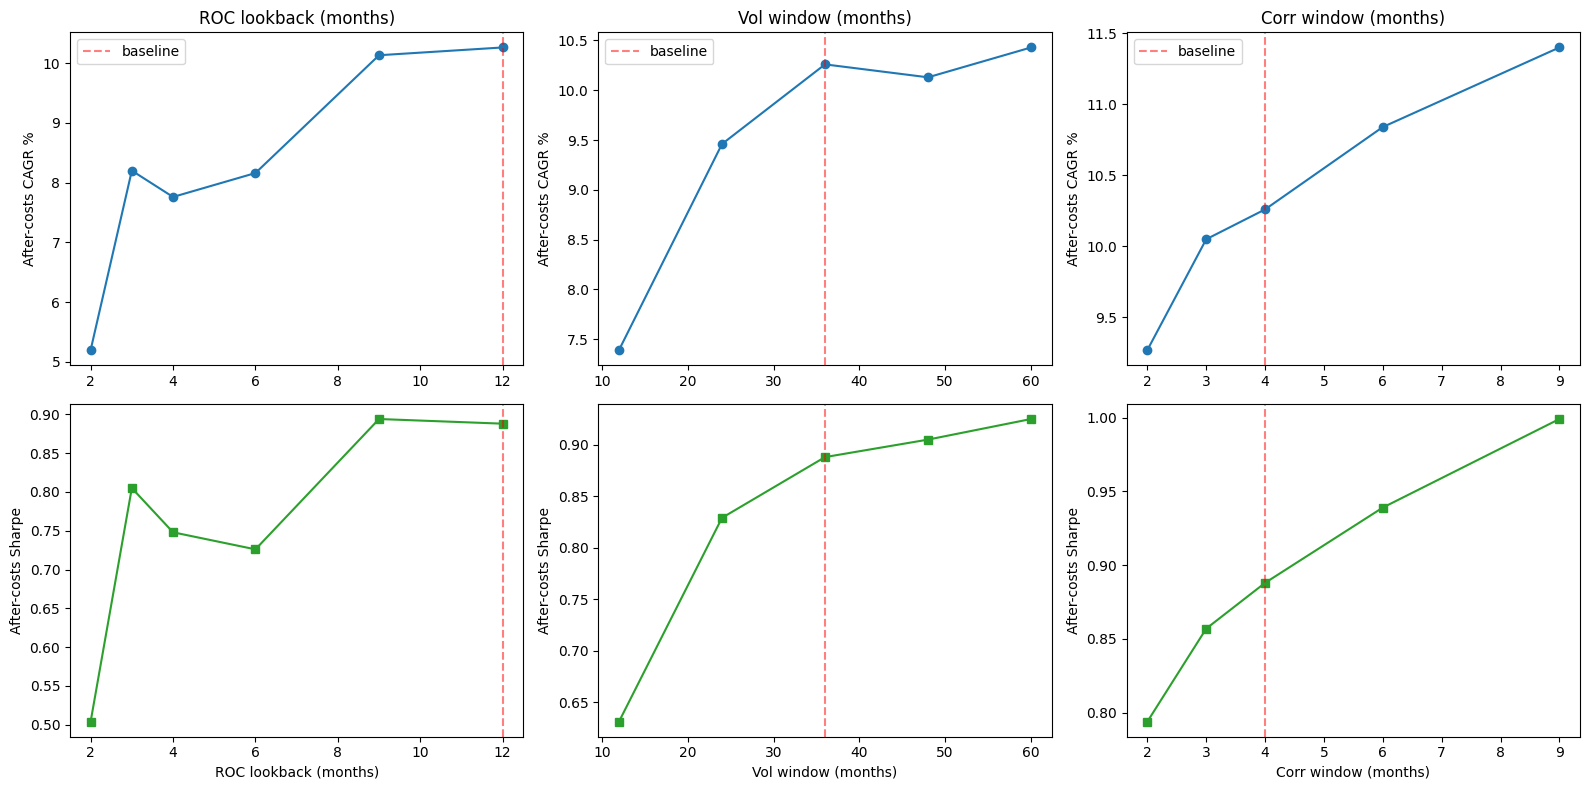

In [10]:
import os
import matplotlib.pyplot as plt

def score(W_sweep, tag):
    """
    Run one sweep point and return its after-costs CAGR and Sharpe.
    We write the weights to a temporary CSV, hand it to the backtest harness,
    delete the temp file, and pull the two numbers we want out of the metrics.
    """
    f = f'_sweep_{tag}.csv'
    W_sweep.to_csv(f)
    r = run_backtest(f, benchmark='SPY', verbose=False,
                     prices=bt_prices, bench_prices=bm_prices)
    os.remove(f)
    cagr = float(r.metrics.loc['Ann. Return (CAGR)', 'Strategy w/ Costs'].rstrip('%'))
    sharpe = float(r.metrics.loc['Sharpe Ratio', 'Strategy w/ Costs'])
    return cagr, sharpe

# --- Define the three sweeps ---
# Each entry is: the build_weights argument to vary, the list of values to try
# (in trading days where the window is daily, in months where it is monthly),
# and the matching labels in months for the x-axis.
sweeps = {
    'ROC lookback (months)': ('roc_period',  [2*21, 3*21, 4*21, 6*21, 9*21, 12*21], [2,3,4,6,9,12]),
    'Vol window (months)':   ('vol_months',  [12, 24, 36, 48, 60],                  [12,24,36,48,60]),
    'Corr window (months)':  ('corr_period', [2*21, 3*21, 4*21, 6*21, 9*21],         [2,3,4,6,9]),
}

# --- Run every sweep point ---
# For each window, step through its values. At each value we rebuild the full
# set of monthly weights with only that one window changed (build_weights keeps
# the other two at their defaults) and score the resulting backtest.
results = {}
for title, (kw, vals, labels) in sweeps.items():
    rows = []
    for v in vals:
        W_s = build_weights(**{kw: v})   # rebuild weights with this one window changed
        rows.append(score(W_s, f'{kw}_{v}'))
    results[title] = (labels, rows)
    print(f"done: {title}")

# --- Plot: two rows (CAGR on top, Sharpe below), one column per window ---
# The red dashed line marks the value we actually use, so you can see at a glance
# whether our choice sits on a flat stretch (good) or on a lonely peak (a warning).
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False)
baseline_x = {'ROC lookback (months)': 12, 'Vol window (months)': 36, 'Corr window (months)': 4}
for j, (title, (labels, rows)) in enumerate(results.items()):
    cagrs = [r[0] for r in rows]
    sharpes = [r[1] for r in rows]
    axes[0, j].plot(labels, cagrs, marker='o')
    axes[0, j].axvline(baseline_x[title], color='red', ls='--', alpha=0.5, label='baseline')
    axes[0, j].set_title(title); axes[0, j].set_ylabel('After-costs CAGR %')
    axes[0, j].legend()
    axes[1, j].plot(labels, sharpes, marker='s', color='tab:green')
    axes[1, j].axvline(baseline_x[title], color='red', ls='--', alpha=0.5)
    axes[1, j].set_xlabel(title); axes[1, j].set_ylabel('After-costs Sharpe')
plt.tight_layout()
plt.show()

The three panels do not all tell the same story, and the differences are the interesting part.

- Momentum lookback: return and Sharpe climb from two months up to about nine, then flatten across the top. Our twelve-month choice sits on that high flat stretch, not on a lonely peak, which is what we want to see for the one setting we deliberately changed from the paper. The four-month value the paper uses sits well down the slope, so the paper is using one of the weaker settings for the factor that matters most.
- Volatility window: a sharp climb up to about twenty-four months, then a plateau out to sixty. Our thirty-six-month choice sits comfortably on the plateau, so the strategy is not sensitive to the exact value here.
- Correlation window: this one does not flatten. Both return and Sharpe rise steadily from two months all the way to nine, and our four-month choice sits low on that rising line.

The correlation panel is worth pausing on, because the natural reaction is to rerun the strategy with a longer correlation window since longer plainly looks better. We are not going to do that, and the reason is the whole point of this section. A monotonic line that keeps rising to the edge of the range is not telling us we found the right window. It is telling us the factor behaves more like a directional dial than a setting with a sensible best value, and a dial that only ever wants to go further is a sign the factor is not contributing in the way it was meant to. Chasing it to nine months, or twelve, or further, would be us tuning a knob to flatter this one slice of history, which is exactly the overfitting the chapter warns against.

There is a cleaner test waiting. Rather than asking what window makes correlation look best, we can ask whether the correlation factor earns its place in the score at all. That is the knockout test, and the spread numbers below set it up by first quantifying how much each window actually moved the result, so we are arguing from sizes rather than from the shape of an autoscaled plot.

In [11]:
# Quantify each sweep's spread instead of eyeballing the autoscaled plots.
for title, (labels, rows) in results.items():
    cagrs = np.array([r[0] for r in rows])
    sharpes = np.array([r[1] for r in rows])
    print(title)
    print(f"  CAGR:   min {cagrs.min():.2f}%  max {cagrs.max():.2f}%  "
          f"spread {cagrs.max()-cagrs.min():.2f} pts  "
          f"(range is {(cagrs.max()-cagrs.min())/cagrs.mean():.0%} of the mean)")
    print(f"  Sharpe: min {sharpes.min():.3f}  max {sharpes.max():.3f}  "
          f"spread {sharpes.max()-sharpes.min():.3f}  "
          f"(range is {(sharpes.max()-sharpes.min())/sharpes.mean():.0%} of the mean)")
    print()

ROC lookback (months)
  CAGR:   min 5.20%  max 10.26%  spread 5.06 pts  (range is 61% of the mean)
  Sharpe: min 0.504  max 0.894  spread 0.390  (range is 51% of the mean)

Vol window (months)
  CAGR:   min 7.39%  max 10.43%  spread 3.04 pts  (range is 32% of the mean)
  Sharpe: min 0.631  max 0.925  spread 0.294  (range is 35% of the mean)

Corr window (months)
  CAGR:   min 9.27%  max 11.40%  spread 2.13 pts  (range is 21% of the mean)
  Sharpe: min 0.794  max 0.999  spread 0.205  (range is 23% of the mean)



The spread numbers put sizes on what the panels showed:

- Momentum lookback is the widest, with after-costs return ranging across 61 percent of its mean and Sharpe across 51 percent. That is a large spread, but recall from the panel it is a steady climb to a high plateau, not a jagged scatter, so it reflects a real directional signal rather than a fragile tuning point.
- Volatility window spreads about 32 percent of mean on return and 35 percent on Sharpe, almost all of it from the single weak twelve-month point at the bottom. From twenty-four months on, the line is flat, so our thirty-six-month choice sits on stable ground.
- Correlation window spreads about 20 percent on return and 23 percent on Sharpe, and unlike the other two this spread is a clean monotonic rise with no plateau. The factor keeps wanting a longer window right to the edge of what we tested.

So the correlation window is the smallest spread of the three in raw size, but it is the one that should give us pause, because its shape never settles. A factor whose best setting is always just past the edge of the test is a factor that is not behaving like a useful, stable input. That observation is what the knockout test pursues next: instead of asking how long the correlation window should be, we ask whether the correlation factor belongs in the score at all.

In [12]:
# --- Knockout test at the 12-month production lookback ---
# Zero each component in turn (spreading its weight across the other three),
# plus momentum-only and the all-equal baseline.
ROC_12 = 12 * 21

configs = {
    'Baseline (all 0.25)':    dict(w_m=.25, w_v=.25, w_c=.25, w_t=.25),
    'No momentum (M=0)':      dict(w_m=0,   w_v=1/3, w_c=1/3, w_t=1/3),
    'No vol (V=0)':           dict(w_m=1/3, w_v=0,   w_c=1/3, w_t=1/3),
    'No corr (C=0)':          dict(w_m=1/3, w_v=1/3, w_c=0,   w_t=1/3),
    'No ATR trend (T=0)':     dict(w_m=1/3, w_v=1/3, w_c=1/3, w_t=0),
    'Momentum only':          dict(w_m=1,   w_v=0,   w_c=0,   w_t=0),
}
rows = []
for name, cfg in configs.items():
    W_s = build_weights(roc_period=ROC_12, **cfg)
    f = '_cfg.csv'; W_s.to_csv(f)
    r = run_backtest(f, benchmark='SPY', verbose=False,
                     prices=bt_prices, bench_prices=bm_prices)
    import os; os.remove(f)
    rows.append({
        'Config': name,
        'CAGR %': float(r.metrics.loc['Ann. Return (CAGR)', 'Strategy w/ Costs'].rstrip('%')),
        'Sharpe': float(r.metrics.loc['Sharpe Ratio', 'Strategy w/ Costs']),
        'MaxDD %': float(r.metrics.loc['Max Drawdown', 'Strategy w/ Costs'].rstrip('%')),
    })
    print(f"done: {name}")

df12 = pd.DataFrame(rows).set_index('Config')
print("\n12-month ROC:")
print(df12.to_string())

done: Baseline (all 0.25)
done: No momentum (M=0)
done: No vol (V=0)
done: No corr (C=0)
done: No ATR trend (T=0)
done: Momentum only

12-month ROC:
                     CAGR %  Sharpe  MaxDD %
Config                                      
Baseline (all 0.25)   10.26   0.888   -19.44
No momentum (M=0)      9.33   0.799   -18.65
No vol (V=0)           8.96   0.751   -19.53
No corr (C=0)         11.62   0.957   -18.19
No ATR trend (T=0)     9.92   0.861   -19.49
Momentum only         11.58   0.916   -18.73


The knockout table makes the complexity point directly. We start from the full four-component baseline at 10.25 percent after costs with a Sharpe of 0.888, then zero each component in turn:

- Dropping correlation does not hurt the strategy, it helps. No-correlation is the best row in the table at 11.62 percent and a Sharpe of 0.957. This is the same message the sweep gave us from a different angle: the correlation factor, as the paper specifies it, is a drag, and the strategy is better off without it.
- Momentum-only is right behind at 11.58 percent and a Sharpe of 0.916. A score built from nothing but the momentum factor very nearly matches the best reduced model and clearly beats the full four-component baseline.
- Dropping volatility is the only change that clearly damages the result, the worst row at 8.96 percent and a Sharpe of 0.751. So volatility is doing real work.
- Dropping the ATR trend term barely moves anything, which is what we expected after seeing how little information that flag carried.

Reading the column as a whole, momentum and volatility are the two factors pulling weight, correlation actively drags, and the trend term is close to inert. The elaborate four-component score is overbuilt: a plain momentum-and-volatility filter would do the job as well or better.

A word on how to read this responsibly, because it is easy to draw the wrong lesson. The tempting move is to point at the no-correlation row, the single best number in the table, and declare that the strategy. That would be a mistake, and it is the same mistake the chapter has warned against throughout: picking the top cell out of six is selecting on one sample of history, and the edge it shows may not survive into the next slice. The defensible takeaway is not any one winning row but the pattern across all of them, which is stable and easy to state. Reducing the model does not cost us anything, and the two factors that matter are momentum and volatility. That is a finding we can trust, where the single best cell is not.

This is the lesson to carry out of the chapter. Complexity has to earn its place. A four-factor composite score looks more sophisticated than a two-factor filter, but sophistication is not the goal, and here the extra factors range from useless to actively harmful. The discipline is to test each piece, keep what pays for itself, and have the restraint to report the robust pattern rather than the prettiest number.

## What the strategy is and what the knockout showed

You have now built the Antifragile Asset Allocation strategy end to end: a monthly rotation across eleven sector funds with a defensive sleeve that fills in when equities weaken and a cash fallback when momentum disappears across the board. You computed the four ranking signals, replicated the paper's slot-filling allocation faithfully, changed the one setting we chose to change (a twelve-month momentum lookback in place of the paper's four), backtested it after costs, and watched it behave as a near-fully-invested equity rotation, around ninety-seven percent in sectors on average, that steps aside only in genuine stress.

The lesson to carry forward is the complexity skepticism the knockout test delivered. A four-component score looks impressive, but taking it apart showed that momentum and a volatility filter do the work, correlation drags, and the trend term is close to inert. The disciplined response was to report the robust pattern across all the variants rather than crown the single best cell, because crowning the best cell is exactly the overfitting that produces strategies that fail out of sample.

## Choosing a fair benchmark

Before we close the strategy out, there is a loose end worth turning into a lesson: what we have been comparing against.

Every result so far has been measured against SPY, a buy-and-hold of the S&P 500. SPY is the obvious yardstick and a fine first reference, but for this strategy it is arguably the wrong one, and seeing why is more useful than the comparison itself.

Think about what this strategy actually does. Its entire job is two things: pick which sectors to hold from month to month, and step aside into defensive assets when those sectors weaken. That is all the active machinery. When we hold it up against SPY, we are not testing those two skills. We are testing them tangled together with a third thing the strategy never tries to do, which is capture the broad return of the whole equity market. SPY carries the large-cap, market-cap-weighted return of the index; our strategy carries an equal-weighted slice of eleven sector funds that steps out in stress. The gap between them mixes the rotation skill with a basket-versus-index difference that has nothing to do with whether the ranking is any good.

A cleaner benchmark holds the strategy's exact universe with none of its cleverness. That is an equal-weight basket of the same eleven sector funds: hold all of them, one eleventh each, all the time, with no ranking and no stepping aside. Now the only difference between the strategy and the benchmark is the rotation and the defensive overlay, because everything else, the universe and the broad sector exposure, is identical on both sides. Whatever the strategy earns or gives up against this basket is the value of its active decisions, cleanly separated from the equity premium.

We add one realistic touch: we rebalance the basket back to equal weight once a year and let the weights drift in between. Drifting weights mean the basket quietly lets its winners run between resets, so it picks up a mild momentum tilt for free, just from doing nothing. That makes it a more demanding test, not a softer one. If our active monthly momentum ranking cannot beat a lazy basket that gets a momentum tilt by accident, that is worth knowing. And a once-a-year rebalance keeps the benchmark's trading costs low, which is the point of a benchmark: it should be the cheap, obvious thing the strategy has to justify itself against.

The question to keep in mind as we build it: the strategy almost certainly gives up some return to a basket that stays fully invested while the strategy sometimes sits in cash. The real test is on risk. If the strategy's stepping aside is worth anything, it should show a shallower worst drawdown than the basket. If the basket matches it on drawdown too, then the defensive overlay is not paying for itself, and that is a finding we would want to face directly rather than hide from.

### Building the equal-weight sector benchmark

We build the benchmark the same way we build the strategy: as a weights file the harness can run, so both go through the identical backtest and the metrics line up for a fair comparison.

The construction is deliberately plain:

- Hold all eleven sector funds at one eleventh each.
- Place a rebalance row on the last trading day of each year, so the weights reset to equal on those dates and drift with prices in between.
- Run it on the same window as the strategy, starting from the first strategy rebalance so the two cover the same period.

The harness applies the same cost treatment it used for the strategy, so the benchmark pays realistic trading costs on its once-a-year reset rather than being handed a costless advantage.

In [13]:
# --- Build an equal-weight sector benchmark with annual (year-end) rebalancing ---
# Same 11 sector funds, 1/11 each, reset on the last trading day of each year.
# Rows only on rebalance dates; the harness holds weights between rows, so the
# basket drifts with prices and resets to equal once a year.

# Use the same trading calendar as the strategy (the downloaded close index),
# and start from the strategy's first rebalance so both cover the same window.
strategy_start = W.index.min()
cal = close.loc[strategy_start:].index

# Last trading day of each calendar year in the window.
year_end_dates = (
    pd.Series(cal, index=cal)
    .groupby(cal.year)
    .last()
    .values
)
year_end_dates = pd.DatetimeIndex(year_end_dates)

# Also seed an opening row on the first date so the basket is invested from day one,
# not only from the first year-end.
rebal_dates = pd.DatetimeIndex([cal[0]]).append(year_end_dates)
rebal_dates = rebal_dates[~rebal_dates.duplicated()].sort_values()

# Equal-weight sector frame: 1/11 in each sector on every rebalance row.
ew = pd.DataFrame(0.0, index=rebal_dates, columns=SECTORS)
ew[SECTORS] = 1.0 / len(SECTORS)

ew_file = 'equal_weight_sectors.csv'
ew.to_csv(ew_file)

print(f"Equal-weight sector benchmark")
print(f"  Sectors held: {len(SECTORS)} at {1/len(SECTORS):.1%} each")
print(f"  Rebalance rows: {len(ew)}  ({ew.index.min().date()} to {ew.index.max().date()})")
print(f"  Rebalance dates:")
print(ew.index.to_series().dt.date.to_string(index=False))

# Run through the same harness, same benchmark argument, same cost treatment.
res_ew = run_backtest(ew_file, benchmark='SPY', verbose=False,
                      prices=bt_prices, bench_prices=bm_prices)
print("\nEqual-weight sector benchmark metrics:")
print(res_ew.metrics.to_string())

Equal-weight sector benchmark
  Sectors held: 11 at 9.1% each
  Rebalance rows: 18  (2010-01-29 to 2026-05-29)
  Rebalance dates:
2010-01-29
2010-12-31
2011-12-30
2012-12-31
2013-12-31
2014-12-31
2015-12-31
2016-12-30
2017-12-29
2018-12-31
2019-12-31
2020-12-31
2021-12-31
2022-12-30
2023-12-29
2024-12-31
2025-12-31
2026-05-29

Equal-weight sector benchmark metrics:
                         Strategy No Cost Strategy w/ Costs SPY Buy & Hold
Total Return                      620.14%           619.62%        842.22%
Ann. Return (CAGR)                 12.78%            12.77%         14.64%
Ann. Volatility                    13.72%            13.73%         14.42%
Downside Deviation                  8.48%             8.49%          8.69%
Max Drawdown                      -23.18%           -23.17%        -23.93%
Max DD Duration (months)               14                14             23
Ulcer Index                         4.390             4.393          5.581
Sharpe Ratio                    

This is a more demanding verdict than SPY gave, and it is the one worth taking seriously.

Set the two after-costs results side by side:

- The strategy returns 10.25 percent a year; the equal-weight basket returns 12.77 percent.
- The strategy's volatility is 11.55 percent against the basket's 13.72 percent.
- The strategy's worst drawdown is 19.48 percent against the basket's 23.13 percent.
- The strategy's Sharpe ratio is 0.888 against the basket's 0.931.

Against SPY we could tell a clean story: the strategy gave up return but won on every risk measure. Against the fairer benchmark that story does not hold. The basket beats the strategy on return and on Sharpe, the return-per-unit-of-risk measure, and the strategy's only clear win is a shallower worst drawdown, about four and a half points less peak-to-trough pain, along with lower volatility.

Sit with what this means. The basket is the lazy option: hold all eleven sectors, reset once a year, do no ranking and no stepping aside. Its after-costs and no-costs returns are almost identical, 12.77 against 12.79, which confirms the once-a-year rebalance costs almost nothing. All of the strategy's monthly ranking, its four-factor score, its defensive overlay, the whole apparatus, delivers less return and a lower Sharpe than that. The active machinery is not buying risk-adjusted outperformance over simply owning the sectors.

What the machinery does buy is a smoother ride in a crisis. The shallower drawdown and lower volatility are real, and they are the product of the strategy stepping into cash and hedges when sectors weaken. For an investor who would abandon a strategy at the bottom of a 23 percent drawdown but could hold through a 19 percent one, that difference has value that the Sharpe ratio does not capture. But we should be fair about the size of the prize: the strategy trades roughly two and a half points of annual return for roughly four and a half points of drawdown relief. Whether that is a good trade depends entirely on the investor, and it is not the free lunch the SPY comparison made it look like.

This is the benchmark lesson in full. Choosing the wrong yardstick flatters a strategy; choosing the right one tells you what your active decisions are actually worth. Here, the right yardstick says the rotation is not adding risk-adjusted value over a plain sector basket, and the defensive overlay is buying drawdown protection at a measurable cost in return. That is a result worth reporting plainly, because it is the kind of result that does not survive being hidden.

There is one lesson here worth keeping. Always test a rotation strategy against an equal-weight basket of its own universe, rebalanced annually. That basket is the cheapest, laziest version of the same bet, and if your active ranking cannot beat it on a risk-adjusted basis, the ranking is not earning the effort it costs to run.

References:
Giordano, Gioele. 2019. "Antifragile Asset Allocation Model." NAAIM Founders Award for Advances in Active Investment Management (First Place). National Association of Active Investment Managers.